In [27]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
DATA_DIR = Path("data")


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

In [29]:
import ast

In [30]:
DATA_FILES = sorted(DATA_DIR.glob("*.json"))

if not DATA_FILES:
    raise FileNotFoundError(f"No JSON files found in {DATA_DIR.resolve()}")

gesture_data = {}
sample_frames = []

for path in DATA_FILES:
    frame = pd.read_json(path, orient="index")
    frame.index.name = "sample_id"
    frame = frame.reset_index()
    frame.insert(0, "gesture_file", path.stem)
    sample_frames.append(frame)
    gesture_data[path.stem] = frame.set_index("sample_id").drop(columns="gesture_file").to_dict(orient="index")

all_data = pd.concat(sample_frames, ignore_index=True)


In [31]:
all_data.to_csv(DATA_DIR / "combined_gesture_data.csv", index=False)

In [32]:
df = pd.read_csv(DATA_DIR / "combined_gesture_data.csv")

In [33]:
df.tail(20)

,gesture_file,sample_id,bboxes,labels,landmarks,leading_conf,leading_hand,user_id
84164,palm,ffd986ce-8c23-43ba-9270-18fa07791200,"[[0.73639257, 0.15635863, 0.11204436, 0.206115...",['palm'],"[[[0.7970673080849571, 0.343595380109781], [0....",1.0,left,e711d3bf230eaccf569f5ceafbd53a2553dc3aab59b4dc...
84165,palm,ffdeaee7-d71f-4862-ada1-232cfeb5e7da,"[[0.15337842000000002, 0.28075954000000003, 0....",['palm'],"[[[0.25945126280811803, 0.571814259890238], [0...",1.0,right,8c42466ad4c45a2ea90144038e00b2560f87beebaf6847...
84166,palm,ffe0b190-1930-40fd-ae46-cb118745fc34,"[[0.24026000000000003, 0.8930028600000001, 0.0...","['no_gesture', 'palm']","[[], [[0.5084663069360971, 0.6073309464444501]...",1.0,left,c7e5009d76794fd9a4445322719cf60454c9ddb4d62b7e...
84167,palm,ffe1acac-d5a8-4ab3-b723-d32056dd48b2,"[[0.32238617, 0.51174296, 0.12415725, 0.105796...",['palm'],"[[[0.374296711567341, 0.607217379384002], [0.3...",1.0,right,2248f3af38316b1394d6c9eb4dc6db5d0eac945bfd6150...
84168,palm,ffe4e1d0-41e9-44fb-9350-9bbf1fee89f4,"[[0.28921159, 0.30940619, 0.14770944, 0.119947...",['palm'],"[[[0.34832926596985303, 0.418156380822338], [0...",1.0,right,caa7b1626db189a5e1701915511aa204b9b8c3db036126...
84169,palm,ffe75bbb-b093-423b-a12b-0b1f2785c9c3,"[[0.21086439999999998, 0.46111629, 0.213420390...",['palm'],"[[[0.300288717346678, 0.616188907475762], [0.3...",0.8,right,c663fe914e7fb4062e38d35242e6b43cfe4b5bbf5cd468...
84170,palm,ffe779f7-cd1e-4006-b677-cf41596f27d3,"[[0.18930259, 0.49488455000000003, 0.119652799...",['palm'],"[[[0.23759719195050802, 0.619583790840674], [0...",1.0,right,bcafcf385345fad80494154255186b5e46ef511fc8c20f...
84171,palm,ffe9aed3-fe72-4634-b59e-f6979b17c299,"[[0.00763093, 0.54871756, 0.47472689999999995,...",['palm'],"[[[0.10638052225112901, 0.8205960541235771], [...",1.0,right,8e81273e5a7246fb2a878e0b6e7288728b91744e4a4528...
84172,palm,ffeb12d1-c818-480a-b4f3-94e4887e8d18,"[[0.45996831, 0.90301986, 0.04188635, 0.078033...","['no_gesture', 'palm']","[[[0.465744013292035, 0.9407980392108201], [0....",1.0,left,cd8d4f5ce07407618a2a54ceefd52ae255f5a5f15660cf...
84173,palm,ffee3d93-6641-4984-8420-9eccb790acc3,"[[0.64748101, 0.52514407, 0.08120642, 0.085336...",['palm'],"[[[0.695989318628184, 0.601024843399098], [0.6...",1.0,left,86d4137ef459829035921c7101bd9f0d10bd0dee48c550...


In [34]:
df.info()
     

<class 'pandas.DataFrame'>
RangeIndex: 84184 entries, 0 to 84183
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   gesture_file  84184 non-null  str    
 1   sample_id     84184 non-null  str    
 2   bboxes        84184 non-null  str    
 3   labels        84184 non-null  str    
 4   landmarks     84184 non-null  str    
 5   leading_conf  84184 non-null  float64
 6   leading_hand  84184 non-null  str    
 7   user_id       84184 non-null  str    
dtypes: float64(1), str(7)
memory usage: 5.1 MB


In [35]:


def contains_no_gesture(value):
    if isinstance(value, list):
        return "no_gesture" in value

    try:
        return "no_gesture" in ast.literal_eval(value)
    except (ValueError, SyntaxError, TypeError):
        return False

df = df.loc[~df["labels"].apply(contains_no_gesture)].reset_index(drop=True)

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65497 entries, 0 to 65496
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   gesture_file  65497 non-null  str    
 1   sample_id     65497 non-null  str    
 2   bboxes        65497 non-null  str    
 3   labels        65497 non-null  str    
 4   landmarks     65497 non-null  str    
 5   leading_conf  65497 non-null  float64
 6   leading_hand  65497 non-null  str    
 7   user_id       65497 non-null  str    
dtypes: float64(1), str(7)
memory usage: 4.0 MB


In [37]:
df.describe(include="all")

,gesture_file,sample_id,bboxes,labels,landmarks,leading_conf,leading_hand,user_id
count,65497,65497,65497,65497,65497,65497.000000,65497,65497
unique,4,65497,65497,4,64990,NaN,2,12526
top,fist,0003d89b-0472-4ad4-80f5-96e9969afff5,"[[0.18547158, 0.30972468000000003, 0.17920195,...",['fist'],[[]],NaN,right,01a1eea072d857da29fbe11a6dae84c8a48e320c24d987...
freq,22008,1,1,22008,507,NaN,35688,223
mean,NaN,NaN,NaN,NaN,NaN,0.991719,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,0.040178,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.600000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


In [38]:
df.isna().sum()

gesture_file    0
sample_id       0
bboxes          0
labels          0
landmarks       0
leading_conf    0
leading_hand    0
user_id         0
dtype: int64

In [39]:
df["gesture_file"].value_counts()

gesture_file
fist    22008
palm    21982
ok      21469
like       38
Name: count, dtype: int64

In [40]:
TARGET = 9000

# Get the original LIKE samples
like_df = df[df["gesture_file"] == "like"].copy()

generated = []

for i in range(TARGET):
    # Randomly select one original sample
    row = like_df.sample(1).iloc[0]

    # Convert string representation into Python list
    landmarks = ast.literal_eval(row["landmarks"])

    # Handle nested format if necessary
    # Example: [[[x,y], [x,y], ...]]
    if len(landmarks) == 1 and isinstance(landmarks[0], list):
        landmarks = landmarks[0]

    landmarks = np.array(landmarks, dtype=np.float32)

    # Small random noise
    noise = np.random.normal(
        loc=0,
        scale=0.005,
        size=landmarks.shape
    )

    new_landmarks = landmarks + noise

    # Keep coordinates inside 0-1
    new_landmarks = np.clip(new_landmarks, 0, 1)

    generated.append({
        "gesture_file": "like",
        "landmarks": new_landmarks.tolist()
    })

augmented_like = pd.DataFrame(generated)

print(len(augmented_like))

9000


In [41]:
augmented_like.head()

,gesture_file,landmarks
0,like,"[[0.47689227255298766, 0.5300648359138329], [0..."
1,like,"[[0.5667718595857153, 0.5314320460671502], [0...."
2,like,"[[0.34365149453003674, 0.7113244512653308], [0..."
3,like,"[[0.367105240595257, 0.5441156623106735], [0.3..."
4,like,"[[0.4626021056802616, 0.8473871708571157], [0...."


In [42]:
df = df[["gesture_file", "landmarks"]]

In [43]:
df = pd.concat(
    [df, augmented_like],
    ignore_index=True
)

In [44]:
df["gesture_file"].value_counts()

gesture_file
fist    22008
palm    21982
ok      21469
like     9038
Name: count, dtype: int64

<Axes: title={'center': 'Number of Samples per Gesture'}>

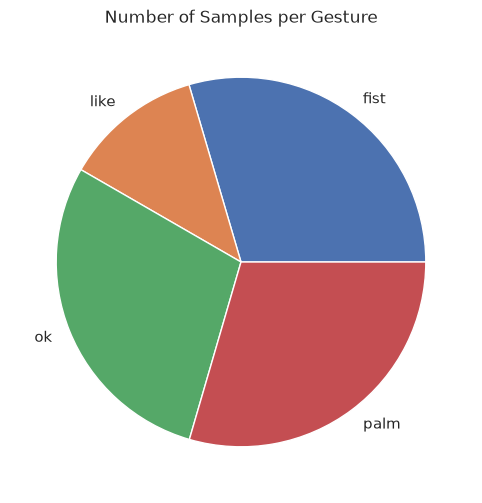

In [45]:
df.groupby("gesture_file").size().plot(kind="pie", figsize=(12, 6), title="Number of Samples per Gesture")

In [46]:
encoder = LabelEncoder()
df["gesture"] = encoder.fit_transform(df["gesture_file"])

In [47]:
df.drop(["gesture_file"], axis=1, inplace=True)

In [48]:
df.head()

,landmarks,gesture
0,"[[[0.24435416045382002, 0.40069063758015505], ...",0
1,"[[[0.136632509531825, 0.7459919332648811], [0....",0
2,"[[[0.30629872929572205, 0.5196072540909571], [...",0
3,"[[[0.37636260570908403, 0.666707215477715], [0...",0
4,"[[[0.322869249992201, 0.29461899575432804], [0...",0


In [49]:
print(encoder.classes_)

['fist' 'like' 'ok' 'palm']


In [50]:
def flatten_landmarks(landmarks):
    return np.array(landmarks).flatten()


In [51]:
X = np.array([
    flatten_landmarks(landmarks)
    for landmarks in df["landmarks"]
])

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (74497,) + inhomogeneous part.

In [ ]:
from collections import Counter

def get_shape(landmarks):
    try:
        arr = np.array(landmarks, dtype=float)
        return arr.shape
    except:
        return "invalid"

shapes = Counter(
    get_shape(x)
    for x in df["landmarks"]
)

print(shapes)

Counter({'invalid': 65497, (21, 2): 8756, (0,): 244})


In [ ]:
print(df["landmarks"].iloc[0])
print(type(df["landmarks"].iloc[0]))

[[[0.24435416045382002, 0.40069063758015505], [0.288713672794704, 0.402054691203427], [0.33223245421371905, 0.38723701121367604], [0.350605991077696, 0.36270089052211], [0.331146401063434, 0.34664377733329704], [0.31159965983250704, 0.348186661265313], [0.31919150838201504, 0.328198292944409], [0.308390213120804, 0.353715352920117], [0.30301627580112, 0.36835533456997804], [0.284798542160835, 0.34301761376974604], [0.291437764494247, 0.32490270582614905], [0.28317454417937205, 0.355397957117743], [0.280466902375826, 0.36733528524270503], [0.257599594554941, 0.341437343710468], [0.26356874671408304, 0.321994771307467], [0.260189096196335, 0.351356360985049], [0.258628446930513, 0.363599767256909], [0.22823427318798903, 0.341773860395979], [0.23570681845138602, 0.32734912937383603], [0.23794818601439002, 0.348087764573666], [0.23855391050962502, 0.35895372052665003]]]
<class 'str'>


In [ ]:
def parse_landmarks(value):
    try:
        # Convert string → Python list
        if isinstance(value, str):
            value = ast.literal_eval(value)

        arr = np.asarray(value, dtype=float)

        # Your example: (1, 21, 2)
        if arr.shape == (1, 21, 2):
            arr = arr[0]

        # Already in desired form
        if arr.shape == (21, 2):
            return arr

        return None

    except (ValueError, SyntaxError, TypeError):
        return None

In [ ]:
df["parsed_landmarks"] = df["landmarks"].apply(parse_landmarks)

print(df["parsed_landmarks"].notna().sum())
print(df["parsed_landmarks"].isna().sum())

73746
751


In [ ]:
# Keep only rows where landmarks were successfully parsed
df = df[df["parsed_landmarks"].notna()].copy()

# Build X
X = np.array([
    landmarks.flatten()
    for landmarks in df["parsed_landmarks"]
])

# Build y
y = df["gesture"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (73746, 42)
y shape: (73746,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
type(y_train)

numpy.ndarray

In [ ]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


In [ ]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [ ]:
y_pred = model.predict(X_test)

In [ ]:

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)


# ============================================================
# 8. Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Accuracy: 0.9981016949152542

Classification Report:
              precision    recall  f1-score   support

        fist       1.00      1.00      1.00      4322
        like       1.00      1.00      1.00      1759
          ok       1.00      1.00      1.00      4280
        palm       1.00      1.00      1.00      4389

    accuracy                           1.00     14750
   macro avg       1.00      1.00      1.00     14750
weighted avg       1.00      1.00      1.00     14750


Confusion Matrix:
[[4315    2    0    5]
 [   0 1759    0    0]
 [   1    0 4266   13]
 [   2    0    5 4382]]


In [ ]:
#joblib.dump(value= model , filename= "gesture detection model.pkl")

['gesture detection model.pkl']

In [52]:
joblib.dump(value= encoder , filename= "gesture detection encoder.pkl")

['gesture detection encoder.pkl']

NameError: name 'train_idx' is not defined

In [55]:
import joblib
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

model = joblib.load("gesture detection model.pkl")

# Make sure X corresponds row-for-row with df
groups = df["user_id"].values

# Check model against each user's data
results = []

for user in np.unique(groups):

    mask = groups == user

    if mask.sum() == 0:
        continue

    X_user = X[mask]
    y_user = y[mask]

    pred = model.predict(X_user)

    acc = accuracy_score(y_user, pred)

    results.append((user, mask.sum(), acc))


# Sort by accuracy
results.sort(key=lambda x: x[2])

for user, samples, acc in results[:20]:
    print(
        f"user={user}, "
        f"samples={samples}, "
        f"accuracy={acc:.4f}"
    )

KeyError: 'user_id'

In [56]:
df.head()

,landmarks,gesture
0,"[[[0.24435416045382002, 0.40069063758015505], ...",0
1,"[[[0.136632509531825, 0.7459919332648811], [0....",0
2,"[[[0.30629872929572205, 0.5196072540909571], [...",0
3,"[[[0.37636260570908403, 0.666707215477715], [0...",0
4,"[[[0.322869249992201, 0.29461899575432804], [0...",0


In [58]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

# Make sure X is numeric
X_check = np.asarray(X, dtype=np.float32)

print("X shape:", X_check.shape)

# ============================================================
# 1. EXACT DUPLICATES
# ============================================================

unique_X, counts = np.unique(
    X_check,
    axis=0,
    return_counts=True
)

duplicate_samples = np.sum(counts > 1)
duplicate_rows = np.sum(counts[counts > 1] - 1)

print("\n========== EXACT DUPLICATES ==========")
print("Unique samples:", len(unique_X))
print("Duplicated groups:", duplicate_samples)
print("Extra duplicate rows:", duplicate_rows)


# ============================================================
# 2. NEAR-DUPLICATES
# ============================================================

# Normalize each landmark vector before distance calculation
norms = np.linalg.norm(X_check, axis=1, keepdims=True)
X_norm = X_check / np.maximum(norms, 1e-8)

# Find nearest neighbor for every sample
nn = NearestNeighbors(
    n_neighbors=2,
    metric="euclidean",
    n_jobs=-1
)

nn.fit(X_norm)

distances, indices = nn.kneighbors(X_norm)

# First neighbor is the sample itself
nearest_distance = distances[:, 1]

print("\n========== NEAR DUPLICATES ==========")

print("Minimum distance:", nearest_distance.min())
print("Mean distance:", nearest_distance.mean())
print("Median distance:", np.median(nearest_distance))

# Try several thresholds
for threshold in [0.001, 0.005, 0.01, 0.02, 0.05]:

    count = np.sum(nearest_distance < threshold)

    percentage = (count / len(X_check)) * 100

    print(
        f"Distance < {threshold}: "
        f"{count} samples ({percentage:.2f}%)"
    )

NameError: name 'X' is not defined

In [59]:
import mediapipe as mp
print("MediaPipe is loading from:", mp.__file__)


MediaPipe is loading from: /home/abdullah-saeed/gesture detection model/.venv/lib/python3.13/site-packages/mediapipe/__init__.py
